In [ ]:
#Carga de bibliotecas
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Cropping2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
from sklearn import metrics

In [2]:
def custom_loss(beta):
    def loss_function(y_true, y_pred):
        # Error cuadrático medio (MSE)
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        
        # Diferencia media entre etiquetas reales y predichas
        mean_diff = tf.reduce_mean(y_true - y_pred)
        
        # Pérdida total
        loss = mse + beta * tf.abs(mean_diff)
        return loss

In [3]:
# Crear el modelo
model = Sequential()
model.add(Input(shape=(144, 192, 1)))
# Capas convolucionales
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
#Capa densa
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))
# Compilar el modelo
optimizer = Adam(learning_rate=1e-3)  
beta=0.1 #Mejores resultados con beta 0.1
model.compile(optimizer=optimizer, loss=custom_loss(beta), metrics=['precision', AUC()])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 144, 192, 64)        │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 72, 96, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 96, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 36, 48, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 18, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 13824)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │          13,825 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 42,177 (164.75 KB)

 Trainable params: 42,177 (164.75 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
#Cargar pesos 
model.load_weights('fold_weights_beta1/fold_4_weights.weights.h5')

C:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# Cargar el archivo JSON a un DataFrame
fold_metrics_beta1 = pd.read_json("fold_metrics_beta1.json")
fold_metrics_beta1

,auc_9,loss,precision,val_auc_9,val_loss,val_precision,auc_10,val_auc_10,auc_11,val_auc_11,auc_12,val_auc_12,auc_13,val_auc_13,auc_14,val_auc_14,auc_15,val_auc_15
0,"[0.460902214050292, 0.48135715723037703, 0.484...","[0.261155158281326, 0.259559988975524, 0.25659...","[0.46621620655059803, 0.0, 0.0, 0.675000011920...","[0.5500249266624451, 0.579392731189727, 0.5542...","[0.25372356176376304, 0.254441022872924, 0.254...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.6363636255264...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,"[0.261708498001098, 0.255422532558441, 0.25715...","[0.47352939844131403, 0.28571429848670904, 0.6...",NaN,"[0.25965911149978604, 0.25600942969322205, 0.2...","[0.22222222387790602, 0.0, 0.357142865657806, ...","[0.46249860525131203, 0.48866188526153503, 0.5...","[0.494708985090255, 0.532275199890136, 0.58571...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,"[0.26063314080238303, 0.25853541493415805, 0.2...","[0.45121949911117504, 0.0, 0.0, 0.0, 0.6666666...",NaN,"[0.26492473483085605, 0.255311012268066, 0.253...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,"[0.44480329751968306, 0.481748849153518, 0.508...","[0.453030288219451, 0.5709596276283261, 0.5636...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,"[0.261483758687973, 0.25766447186470004, 0.255...","[0.43928572535514804, 0.0, 0.0, 0.0, 0.6024096...",NaN,"[0.257761240005493, 0.26659533381462003, 0.259...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.8571428656578061, ...",NaN,NaN,NaN,NaN,"[0.46965405344963, 0.509906291961669, 0.502649...","[0.49491867423057506, 0.515243887901306, 0.555...",NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,"[0.260178595781326, 0.256177961826324, 0.25652...","[0.47586205601692205, 0.4375, 1.0, 0.557692289...",NaN,"[0.25512188673019404, 0.25931122899055403, 0.2...","[0.47058823704719505, 0.0, 0.0, 0.553846180438...",NaN,NaN,NaN,NaN,NaN,NaN,"[0.497684180736541, 0.5040544867515561, 0.5254...","[0.5010111331939691, 0.464357912540435, 0.4883...",NaN,NaN,NaN,NaN
5,NaN,"[0.263260930776596, 0.256273567676544, 0.25470...","[0.33333334326744, 0.480769217014312, 0.5, 0.5...",NaN,"[0.255538403987884, 0.25581112504005404, 0.254...","[0.0, 0.28571429848670904, 0.28571429848670904...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.40162834525108304, 0.491501629352569, 0.517...","[0.44157895445823603, 0.424210548400878, 0.403...",NaN,NaN
6,NaN,"[0.26120868325233404, 0.260493576526641, 0.257...","[0.47402596473693803, 0.699999988079071, 0.413...",NaN,"[0.256702452898025, 0.25449752807617104, 0.263...","[0.0, 0.0, 0.0, 0.48571428656578003, 0.0, 1.0,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.49359995126724204, 0.43231400847435, 0.4853...","[0.47954541444778404, 0.546464622020721, 0.521..."


In [6]:
Roc=fold_metrics_beta1["auc_13"][4]
Roc_val=fold_metrics_beta1["val_auc_13"][4]
LOSS=fold_metrics_beta1["loss"][4]
LOSS_val=fold_metrics_beta1["val_loss"][4]
Precision=fold_metrics_beta1["precision"][4]
Precision_val=fold_metrics_beta1["val_precision"][4]

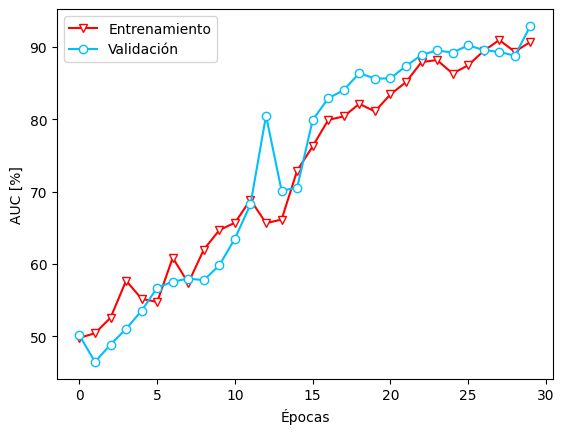

In [76]:
# Grafica ROC de entrenamiento y de validación
plt.plot(100*np.array(Roc), label='Entrenamiento',marker='v',markersize=6,color="red",markerfacecolor='white')
plt.plot(100*np.array(Roc_val), label='Validación',marker='o',markersize=6,color="deepskyblue",markerfacecolor='white')
#plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.xlabel('Épocas')
plt.ylabel('AUC [%]')
plt.legend()
plt.savefig("GraficaRoc.png")
plt.show()


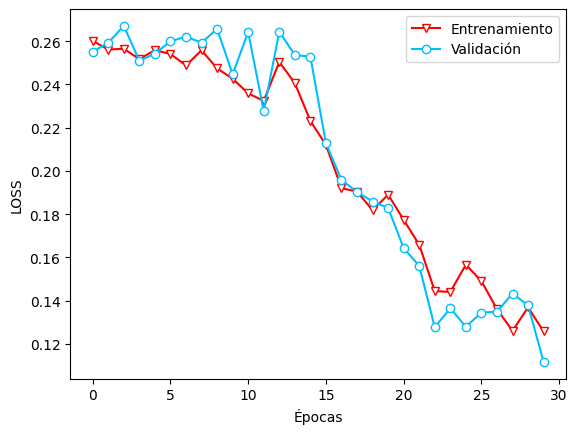

In [11]:
# Grafica ROC de entrenamiento y de validación
plt.plot(np.array(LOSS), label='Entrenamiento',marker='v',markersize=6,color="red",markerfacecolor='white')
plt.plot(np.array(LOSS_val), label='Validación',marker='o',markersize=6,color="deepskyblue",markerfacecolor='white')
#plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.xlabel('Épocas')
plt.ylabel('LOSS')
plt.legend()
plt.savefig("GraficaLOSS.png")
plt.show()

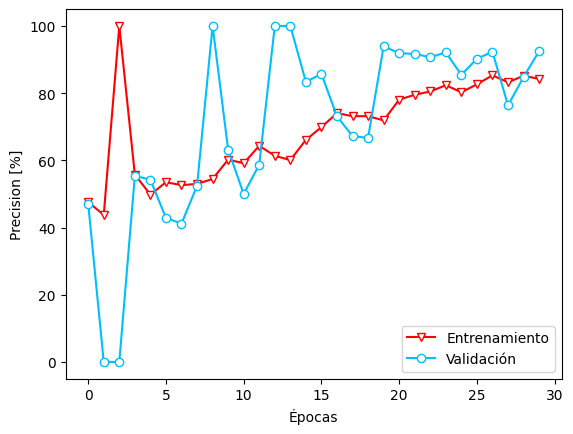

In [12]:
# Grafica ROC de entrenamiento y de validación
plt.plot(100*np.array(Precision), label='Entrenamiento',marker='v',markersize=6,color="red",markerfacecolor='white')
plt.plot(100*np.array(Precision_val), label='Validación',marker='o',markersize=6,color="deepskyblue",markerfacecolor='white')
#plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.xlabel('Épocas')
plt.ylabel('Precision [%]')
plt.legend()
plt.savefig("GraficaPrecision.png")
plt.show()

In [5]:
train_dir="datasets/GrupoControl/train/"

train_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_dir,
    color_mode='grayscale',
    target_size=(144, 192),
    class_mode='binary',
    shuffle=False
)

# Predecir entrenamiento
predictions=model.predict(train_generator)

# Pasar de probabilidad a etiquetas
train_predicted_classes = (predictions > 0.5).astype(int)  
train_true_classes = train_generator.classes

Found 623 images belonging to 2 classes.


C:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step


<Figure size 800x600 with 0 Axes>

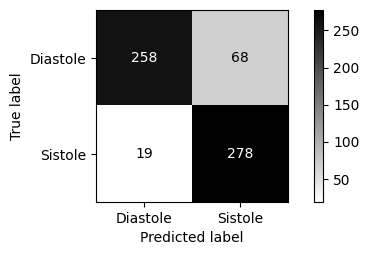

In [18]:
# Suponiendo que ya tienes las variables train_true_classes y train_predicted_classes definidas
train_cm = confusion_matrix(train_true_classes, train_predicted_classes)

# Crea el gráfico con un tamaño ajustado
plt.figure(figsize=(8, 6))  # Cambia el tamaño de la figura

# Mostrar la matriz de confusión
disp = ConfusionMatrixDisplay(train_cm, display_labels=train_generator.class_indices.keys())
disp.plot(cmap="binary", values_format='d')  # `values_format='d'` para mostrar números enteros

# Ajustar los márgenes si es necesario
plt.subplots_adjust(left=0.1, right=0.9, top=0.5, bottom=0.1)  # Ajusta según sea necesario

# Cambiar el tamaño de la fuente en las etiquetas
#plt.title("Matriz de Confusión - Entrenamiento", fontsize=14)  # Puedes ajustar el tamaño de la fuente aquí
plt.savefig("GraficaMatrizConfusionEntrenamiento.png")

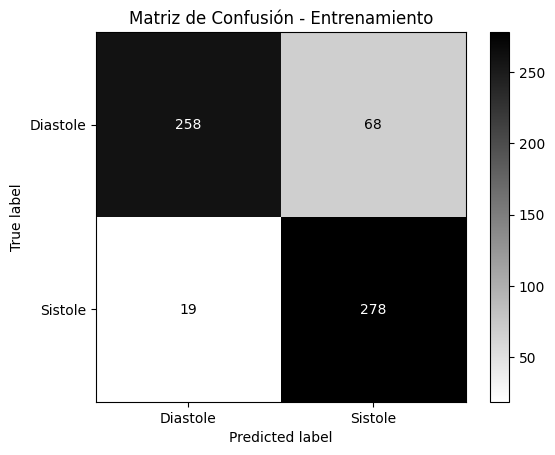

In [7]:
train_cm = confusion_matrix(train_true_classes, train_predicted_classes)
ConfusionMatrixDisplay(train_cm, display_labels=train_generator.class_indices.keys()).plot(cmap="binary")
plt.title("Matriz de Confusión - Entrenamiento")
plt.savefig("GraficaMatrizConfusionEntrenamiento.png")
plt.show()

In [14]:
test_dir="datasets/GrupoControl/test/"

test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    color_mode='grayscale',
    target_size=(144, 192),
    class_mode='binary',
    shuffle=False
)

# Predecir entrenamiento
predictions=model.predict(test_generator)

# Pasar de probabilidad a etiquetas
test_predicted_classes = (predictions > 0.5).astype(int)  
test_true_classes = test_generator.classes

Found 157 images belonging to 2 classes.


C:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step


<Figure size 800x600 with 0 Axes>

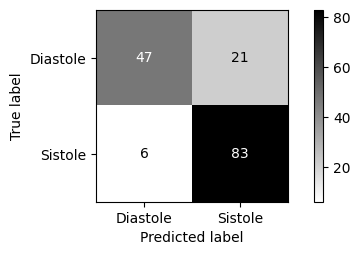

In [21]:
# Suponiendo que ya tienes las variables train_true_classes y train_predicted_classes definidas
test_cm = confusion_matrix(test_true_classes, test_predicted_classes)

# Crea el gráfico con un tamaño ajustado
plt.figure(figsize=(8, 6))  # Cambia el tamaño de la figura

# Mostrar la matriz de confusión
disp = ConfusionMatrixDisplay(test_cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="binary", values_format='d')  # `values_format='d'` para mostrar números enteros

# Ajustar los márgenes si es necesario
plt.subplots_adjust(left=0.1, right=0.9, top=0.5, bottom=0.1)  # Ajusta según sea necesario

# Cambiar el tamaño de la fuente en las etiquetas
#plt.title("Matriz de Confusión - Entrenamiento", fontsize=14)  # Puedes ajustar el tamaño de la fuente aquí
plt.savefig("GraficaMatrizConfusionTest.png")

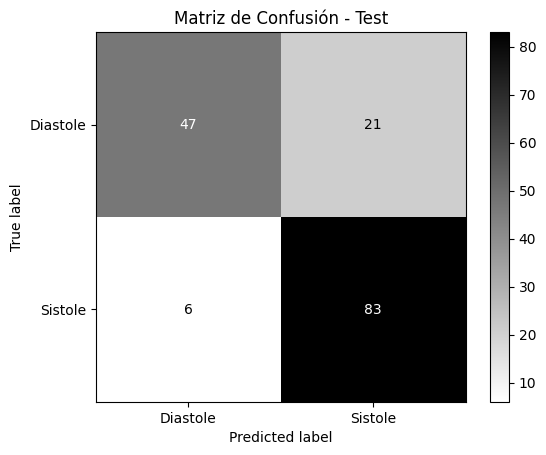

In [15]:
test_cm = confusion_matrix(test_true_classes, test_predicted_classes)
ConfusionMatrixDisplay(test_cm, display_labels=test_generator.class_indices.keys()).plot(cmap="binary")
plt.title("Matriz de Confusión - Test")
plt.savefig("GraficaMatrizConfusionTest.png")
plt.show()

In [41]:
tn, fp, fn, tp = test_cm.ravel()

In [68]:
accuracy=(tp+tn)/(tp+fp+tn+fn)
#Sensitvity
sn=tp/(tp+fn)
# Specificity
sp=tn/(tn+fp)
# Precision
p=tp/(tp+fp)
# Recall 
r=tp/(tp+fn)
f1=2*p*r/(p+r)
GM=np.sqrt(tp*tn)
print("Acurracy:",accuracy.round(2))
print("Sensitivity:",sn.round(2))
print("Specificity:",sp.round(2))
print("Precisión:",p.round(2))
print("Recall:",r.round(2))
print("F1:",f1.round(2))
print("Geometric Mean:",GM.round(2))

Acurracy: 0.83
Sensitivity: 0.93
Specificity: 0.69
Precisión: 0.8
Recall: 0.93
F1: 0.86
Geometric Mean: 62.46


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step


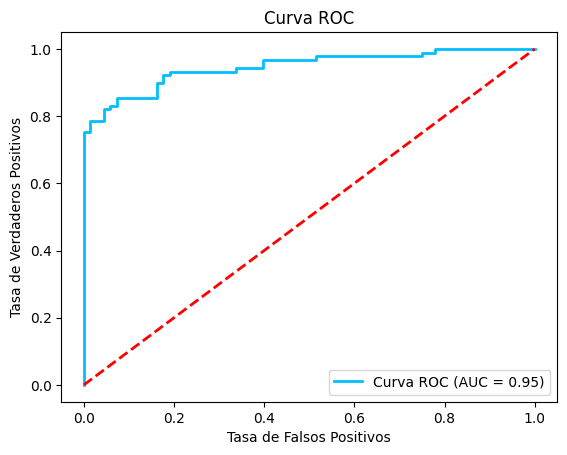

In [ ]:
# Probabilidades predichas
y_pred_prob = model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)

# TRUE
y_true = test_generator.classes

# Calcula la curva ROC
fpr, tpr, thresholds =metrics.roc_curve(y_true, y_pred_prob)

# AUC
roc_auc = metrics.auc(fpr, tpr)

# Grafica curva ROC
plt.figure()
plt.plot(fpr, tpr, color='deepskyblue', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')  # Línea diagonal
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.savefig("GraficaCurvaROC.png")

plt.show()
